#**TIDAK PERLU DIDOWNLOAD**
### CUKUP MODIFIKASI LANGSUNG DI GCOLLAB AGAR UPDATE BISA DILIHAT ANGGOTA YANG LAINNYA

# DATA UNDERSTANDING
## Dry Bean Dataset — Klasifikasi dengan KNN, Decision Tree, dan Naive Bayes


## 1. Data Understanding


### 1.1 Deskripsi Dataset

Dataset ini berisi hasil pengamatan visual dari 7 jenis biji kacang kering yang berbeda, diambil menggunakan sistem visi komputer.

| Info | Detail |
|---|---|
| Jumlah Data | 13.611 baris |
| Jumlah Fitur | 16 fitur numerik |
| Target | 7 kelas jenis kacang |

##### Kelas Target:
- SEKER
- BARBUNYA
- BOMBAY
- CALI
- DERMASON
- HOROZ
- SIRA

##### Deskripsi Fitur:

| Fitur | Deskripsi |
|---|---|
| Area | Luas area biji (piksel) |
| Perimeter | Keliling biji |
| MajorAxisLength | Panjang sumbu utama ellips |
| MinorAxisLength | Panjang sumbu minor ellips |
| AspectRation | Rasio sumbu utama terhadap sumbu minor |
| Eccentricity | Eksentrisitas ellips |
| ConvexArea | Luas area cembung biji |
| EquivDiameter | Diameter lingkaran ekuivalen |
| Extent | Rasio area biji terhadap bounding box |
| Solidity | Rasio area terhadap convex area |
| roundness | Tingkat kebulatan biji |
| Compactness | Kekompakan bentuk biji |
| ShapeFactor1 | Faktor bentuk 1 |
| ShapeFactor2 | Faktor bentuk 2 |
| ShapeFactor3 | Faktor bentuk 3 |
| ShapeFactor4 | Faktor bentuk 4 |

### 1.2 Import Library


In [4]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score
)

from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression

print("Semua library berhasil diimport!")

Semua library berhasil diimport!


### 1.3 Load Dataset


In [ ]:
df = pd.read_excel('sample_data/Dry_Bean_Dataset.xlsx')
print(f"Ukuran Dataset: {df.shape[0]} baris x {df.shape[1]} kolom")

Ukuran Dataset: 13611 baris x 17 kolom


### 1.4 Tipe data dan struktur kolom


In [ ]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  object 
dtypes: float64(1

### 1.6 Deskripsi Statistik


## 2. Exploratory Data Analysis (EDA)


### 2.1 Cek Missing Value



                  Jumlah Missing  Persentase (%)
Area                          0             0.0
Perimeter                     0             0.0
MajorAxisLength               0             0.0
MinorAxisLength               0             0.0
AspectRation                  0             0.0
Eccentricity                  0             0.0
ConvexArea                    0             0.0
EquivDiameter                 0             0.0
Extent                        0             0.0
Solidity                      0             0.0
roundness                     0             0.0
Compactness                   0             0.0
ShapeFactor1                  0             0.0
ShapeFactor2                  0             0.0
ShapeFactor3                  0             0.0
ShapeFactor4                  0             0.0
Class                         0             0.0

Total missing value: 0
Tidak ada missing value pada dataset.


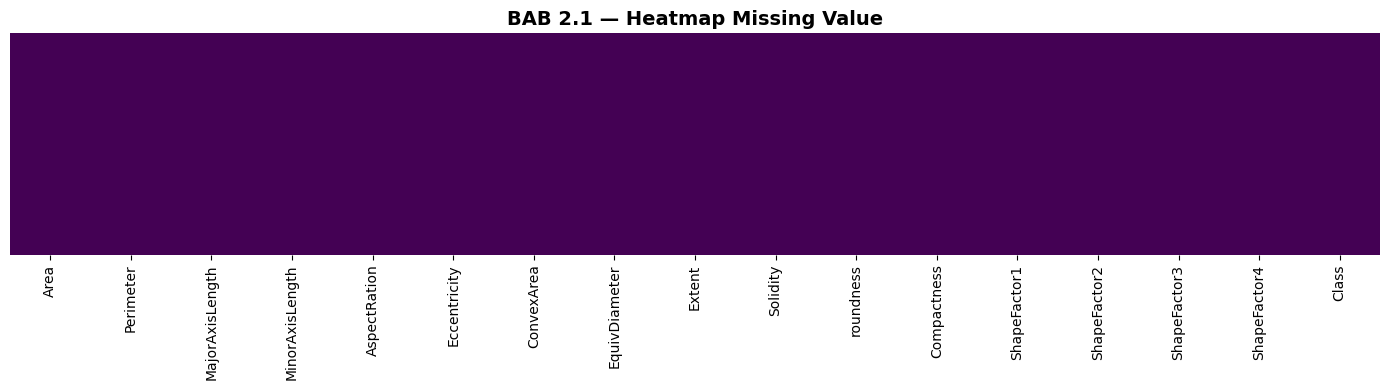

In [ ]:
missing     = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df  = pd.DataFrame({
    "Jumlah Missing": missing,
    "Persentase (%)": missing_pct
})
print("\n", missing_df)
print(f"\nTotal missing value: {missing.sum()}")

if missing.sum() == 0:
    print("Tidak ada missing value pada dataset.")
else:
    print("Terdapat missing value, perlu penanganan lebih lanjut.")

# Visualisasi
plt.figure(figsize=(14, 4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("BAB 2.1 — Heatmap Missing Value", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("2.1_missing_value.png", dpi=150)
plt.show()

### 2.2 Cek Data Duplikat


Jumlah baris duplikat: 68
Terdapat 68 baris duplikat.

Contoh baris duplikat:
       Area  Perimeter  MajorAxisLength  MinorAxisLength  AspectRation  \
5505  33518    702.956       277.571399       154.305581      1.798842   
5509  33954    716.750       277.368480       156.356326      1.773951   
5548  38427    756.323       306.533886       160.591784      1.908777   
5554  38891    791.343       319.499996       156.869619      2.036723   
5599  40804    790.802       323.475648       163.287717      1.981016   

      Eccentricity  ConvexArea  EquivDiameter    Extent  Solidity  roundness  \
5505      0.831240       34023     206.582775  0.808383  0.985157   0.852377   
5509      0.825970       34420     207.922042  0.799482  0.986461   0.830549   
5548      0.851782       38773     221.193978  0.796976  0.991076   0.844174   
5554      0.871168       39651     222.525412  0.650025  0.980833   0.780422   
5599      0.863241       41636     227.932592  0.787570  0.980017   0.819931 

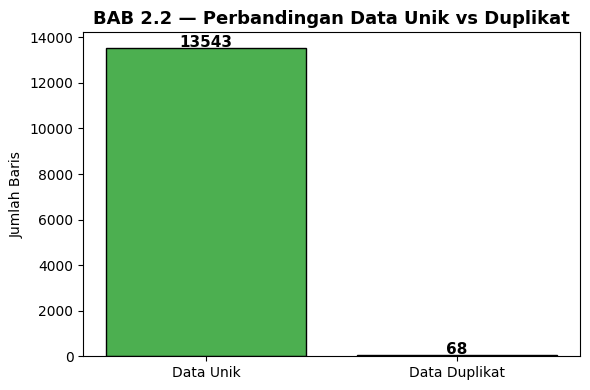

In [9]:
n_dup = df.duplicated().sum()
print(f"Jumlah baris duplikat: {n_dup}")

if n_dup == 0:
    print("Tidak ada data duplikat.")
else:
    print(f"Terdapat {n_dup} baris duplikat.")
    print("\nContoh baris duplikat:")
    print(df[df.duplicated()].head())

# Visualisasi
labels = ["Data Unik", "Data Duplikat"]
values = [len(df) - n_dup, n_dup]
colors = ["#4CAF50", "#F44336"]

plt.figure(figsize=(6, 4))
bars = plt.bar(labels, values, color=colors, edgecolor="black")
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
             str(val), ha="center", fontsize=11, fontweight="bold")
plt.title("BAB 2.2 — Perbandingan Data Unik vs Duplikat",
          fontsize=13, fontweight="bold")
plt.ylabel("Jumlah Baris")
plt.tight_layout()
plt.savefig("2.2_duplikat.png", dpi=150)
plt.show()


### 2.3 Distribusi Kelas (Class Distribution)


          Jumlah  Persentase (%)
Class                           
DERMASON    3546           26.05
SIRA        2636           19.37
SEKER       2027           14.89
HOROZ       1928           14.17
CALI        1630           11.98
BARBUNYA    1322            9.71
BOMBAY       522            3.84


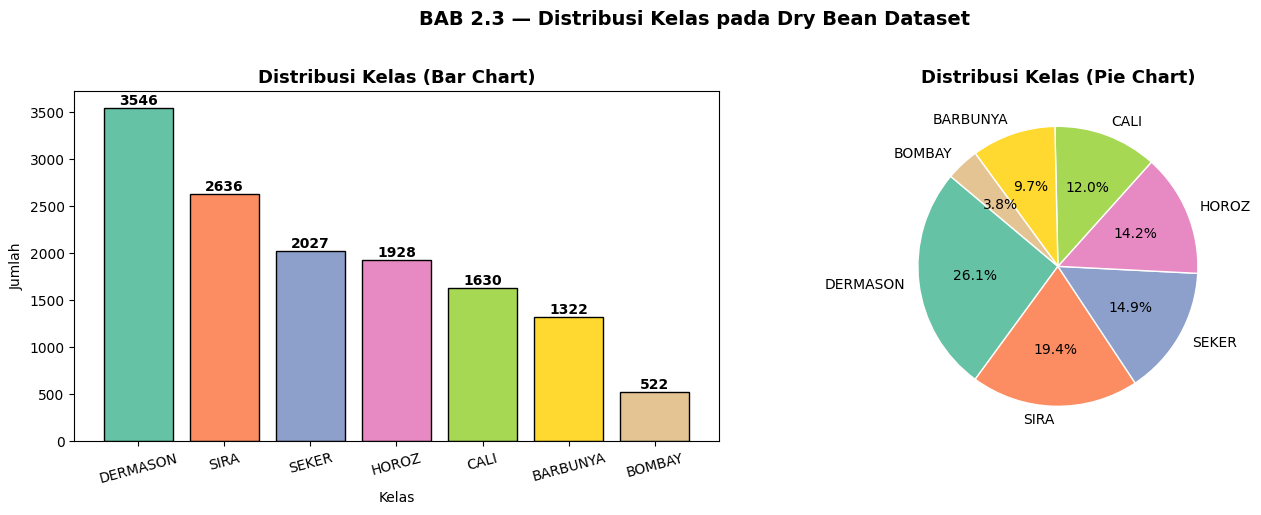

In [8]:
class_counts = df["Class"].value_counts()
class_pct    = (class_counts / len(df) * 100).round(2)
class_df     = pd.DataFrame({"Jumlah": class_counts, "Persentase (%)": class_pct})
print(class_df)

palette = sns.color_palette("Set2", len(class_counts))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar Chart
axes[0].bar(class_counts.index, class_counts.values, color=palette, edgecolor="black")
for i, (cls, val) in enumerate(zip(class_counts.index, class_counts.values)):
    axes[0].text(i, val + 30, str(val), ha="center", fontsize=10, fontweight="bold")
axes[0].set_title("Distribusi Kelas (Bar Chart)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Kelas")
axes[0].set_ylabel("Jumlah")
axes[0].tick_params(axis="x", rotation=15)

# Pie Chart
axes[1].pie(class_counts.values, labels=class_counts.index,
            autopct="%1.1f%%", colors=palette, startangle=140,
            wedgeprops=dict(edgecolor="white"))
axes[1].set_title("Distribusi Kelas (Pie Chart)", fontsize=13, fontweight="bold")

plt.suptitle("BAB 2.3 — Distribusi Kelas pada Dry Bean Dataset",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("2.3_distribusi_kelas.png", dpi=150, bbox_inches="tight")
plt.show()


### 2.4 Distribusi Setiap Fitur (Histogram)


Fitur numerik (16): ['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent', 'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor3', 'ShapeFactor4']


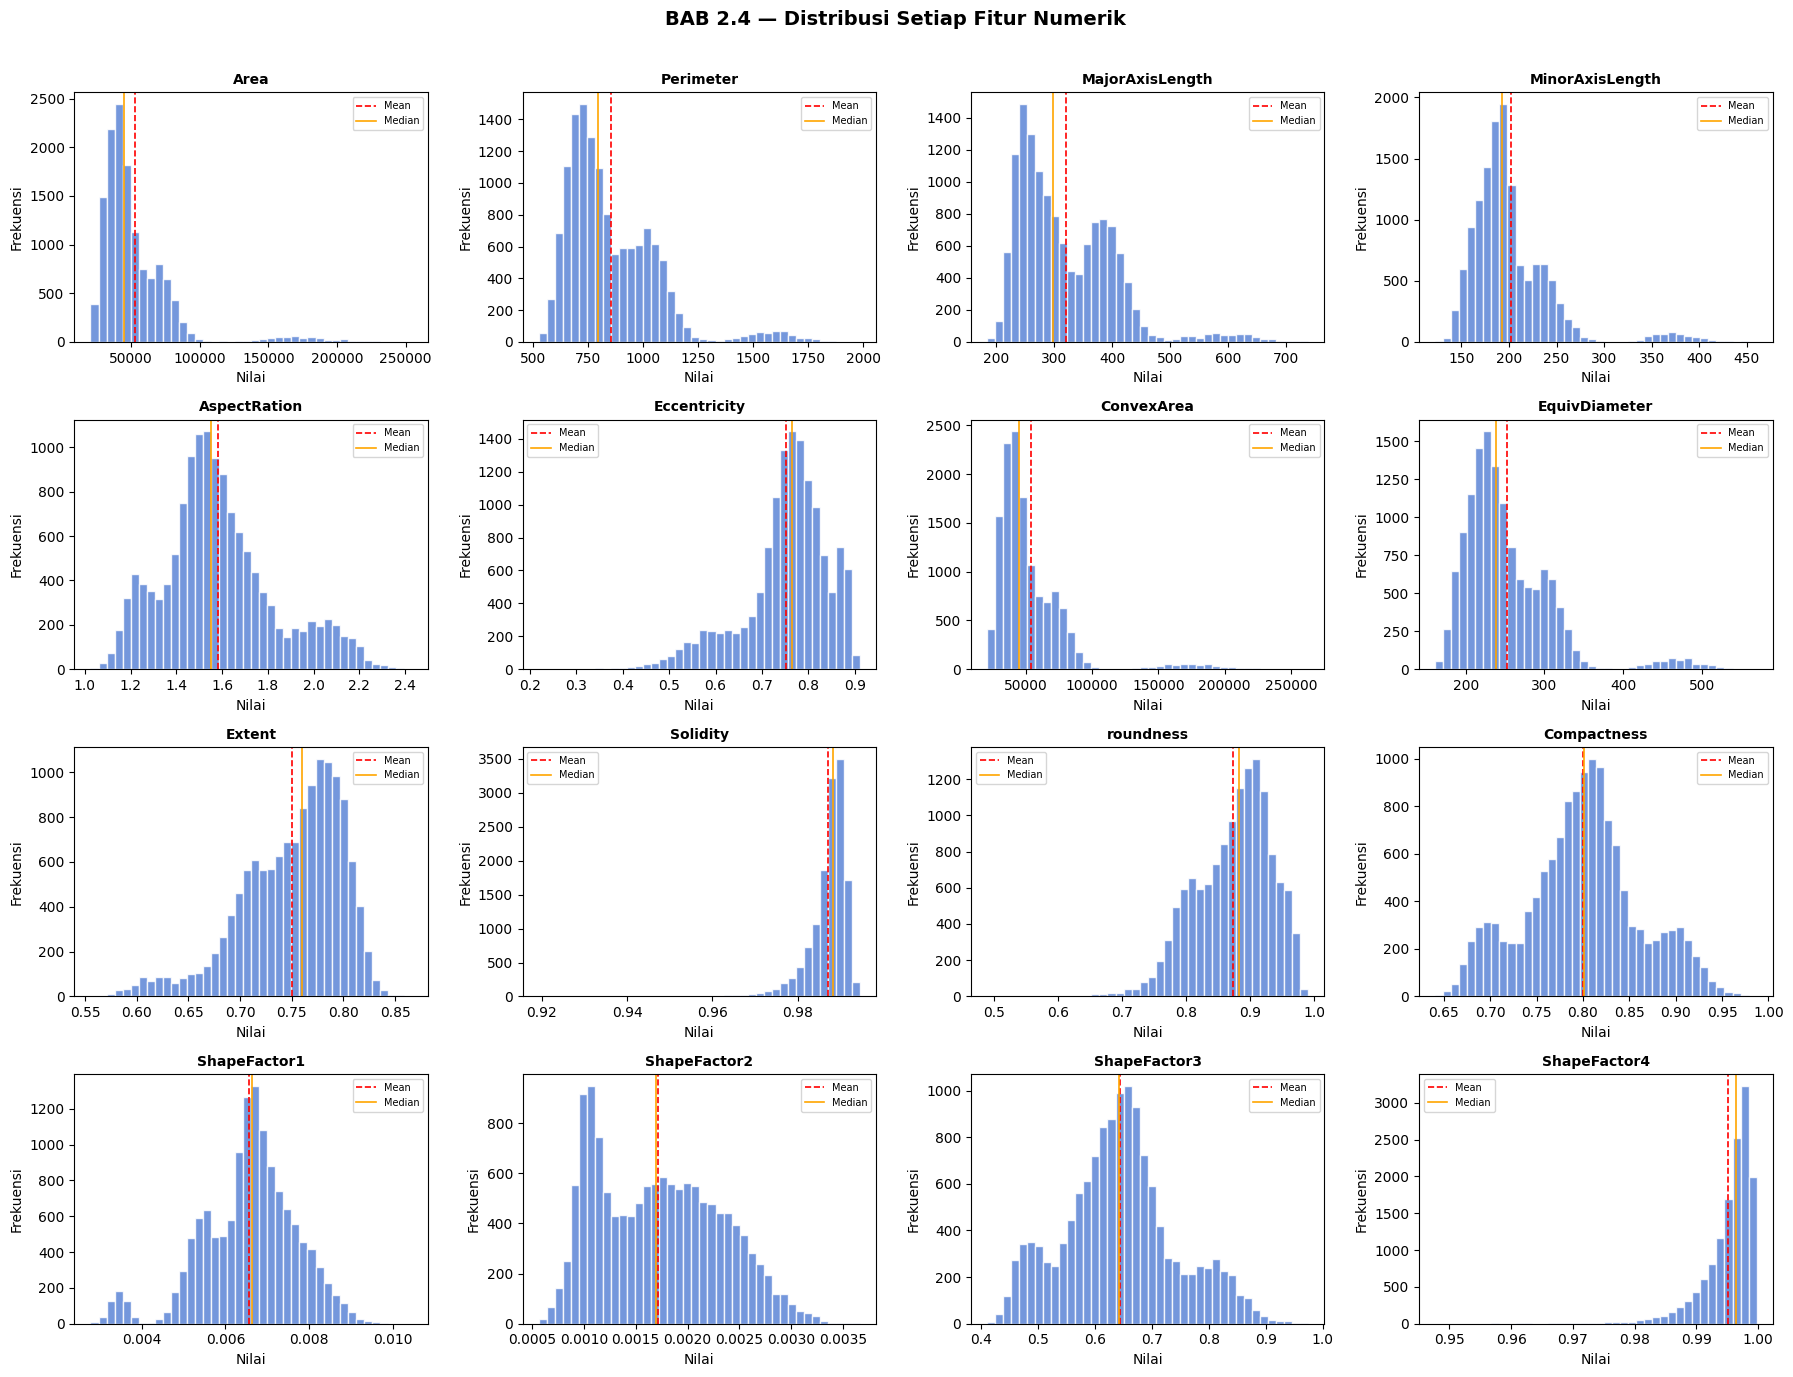


Statistik Deskriptif:
                   count       mean        std        min        25%  \
Area             13611.0  53048.285  29324.096  20420.000  36328.000   
Perimeter        13611.0    855.283    214.290    524.736    703.523   
MajorAxisLength  13611.0    320.142     85.694    183.601    253.304   
MinorAxisLength  13611.0    202.271     44.970    122.513    175.848   
AspectRation     13611.0      1.583      0.247      1.025      1.432   
Eccentricity     13611.0      0.751      0.092      0.219      0.716   
ConvexArea       13611.0  53768.200  29774.916  20684.000  36714.500   
EquivDiameter    13611.0    253.064     59.177    161.244    215.068   
Extent           13611.0      0.750      0.049      0.555      0.719   
Solidity         13611.0      0.987      0.005      0.919      0.986   
roundness        13611.0      0.873      0.060      0.490      0.832   
Compactness      13611.0      0.800      0.062      0.641      0.762   
ShapeFactor1     13611.0      0.007      

In [10]:
features = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Fitur numerik ({len(features)}): {features}")

# Visualisasi
n_cols = 4
n_rows = int(np.ceil(len(features) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.5))
axes = axes.flatten()

for i, feat in enumerate(features):
    axes[i].hist(df[feat], bins=40, color="#5C85D6", edgecolor="white", alpha=0.85)
    axes[i].set_title(feat, fontsize=10, fontweight="bold")
    axes[i].set_xlabel("Nilai")
    axes[i].set_ylabel("Frekuensi")
    axes[i].axvline(df[feat].mean(),   color="red",    linestyle="--", linewidth=1.2, label="Mean")
    axes[i].axvline(df[feat].median(), color="orange", linestyle="-",  linewidth=1.2, label="Median")
    axes[i].legend(fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("BAB 2.4 — Distribusi Setiap Fitur Numerik",
             fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig("2.4_distribusi_fitur.png", dpi=150, bbox_inches="tight")
plt.show()

# Statistik Deskriptif
print("\nStatistik Deskriptif:")
print(df[features].describe().round(3).T)


### 2.5 Deteksi Outlier (Boxplot)


### 2.6 Analisis Korelasi Antar Fitur (Heatmap)


### 2.7 Distribusi Fitur per Kelas (Boxplot per Class)


### 2.8 Pairplot Fitur Terpilih


### 2.9 Violin Plot Fitur Terpilih per Kelas


## 3. Preprocessing


### 3.1 Handling Missing Value


### 3.2 Handling Outlier


### 3.3 Encoding Label Target


### 3.4 Pemisahan Fitur dan Target (X dan y)


### 3.5 Split Data (Train dan Test)


### 3.6 Feature Scaling (Standarisasi)


## 4. Feature Selection


### 4.1 Analisis Fitur Berkorelasi Tinggi


### 4.2 Seleksi Fitur Berdasarkan Korelasi


### 4.3 Visualisasi Fitur yang Dipilih


## 5. Pemodelan


### 5.1 K-Nearest Neighbors (KNN)


#### 5.1.1 Menentukan Nilai K Optimal


Menggunakan variabel df yang sudah ada di memory.
X_train=(10888, 16), X_test=(2723, 16)
Label kelas: ['BARBUNYA', 'BOMBAY', 'CALI', 'DERMASON', 'HOROZ', 'SEKER', 'SIRA']

Hasil pencarian nilai K optimal:
 K  Mean CV Accuracy
 1          0.906226
 3          0.917432
 5          0.921289
 7          0.923953
 9          0.924137
11          0.923953
13          0.924504
15          0.924137
17          0.925606
19          0.926250
21          0.926984
23          0.925331
25          0.925055

Nilai K terbaik: 21 dengan rata-rata akurasi CV 0.9270


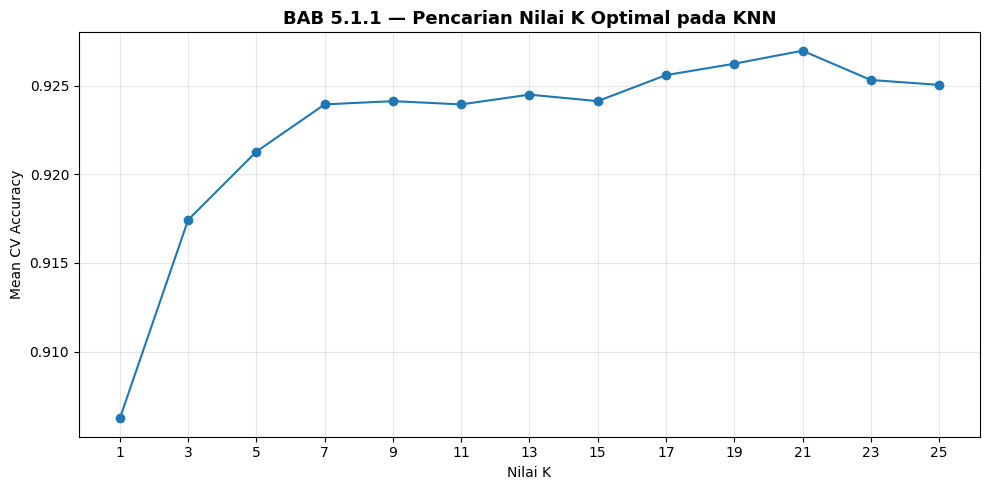

In [2]:
# 5.1.1 Menentukan Nilai K Optimal
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier

# 1) Jika df sudah ada dari cell sebelumnya, pakai itu agar tidak bergantung path file.
use_existing_df = ('df' in globals()) and isinstance(df, pd.DataFrame) and ('Class' in df.columns)

if not use_existing_df:
    # 2) Cari dataset di beberapa lokasi umum (lokal + Google Colab)
    candidate_paths = [
        'Dry_Bean_Dataset.xlsx',
        'sample_data/Dry_Bean_Dataset.xlsx',
        '/content/Dry_Bean_Dataset.xlsx',
        '/content/sample_data/Dry_Bean_Dataset.xlsx',
        '/content/drive/MyDrive/Dry_Bean_Dataset.xlsx',
        '/content/drive/MyDrive/UTS/Dry_Bean_Dataset.xlsx',
    ]

    dataset_path = next((p for p in candidate_paths if os.path.exists(p)), None)

    if dataset_path is None:
        # 3) Jika di Colab, coba mount Google Drive otomatis lalu cari lagi.
        try:
            import google.colab  # type: ignore
            from google.colab import drive  # type: ignore
            if not os.path.exists('/content/drive'):
                drive.mount('/content/drive')
            elif not os.path.exists('/content/drive/MyDrive'):
                drive.mount('/content/drive')
        except Exception:
            pass

        dataset_path = next((p for p in candidate_paths if os.path.exists(p)), None)

    if dataset_path is None:
        # 4) Fallback: cari rekursif di folder kerja/drive.
        search_roots = [Path('.'), Path('/content'), Path('/content/drive/MyDrive')]
        for root in search_roots:
            if root.exists():
                matches = list(root.rglob('Dry_Bean_Dataset.xlsx'))
                if matches:
                    dataset_path = str(matches[0])
                    break

    if dataset_path is None:
        raise FileNotFoundError(
            "File Dry_Bean_Dataset.xlsx tidak ditemukan. "
            "Upload file ke Colab (ikon folder -> Upload) atau pastikan ada di Google Drive/MyDrive. "
            "Nama file harus: Dry_Bean_Dataset.xlsx"
        )

    df = pd.read_excel(dataset_path)
    print(f"Data dibaca dari file: {dataset_path}")
else:
    print("Menggunakan variabel df yang sudah ada di memory.")

if 'Class' not in df.columns:
    raise ValueError("Kolom target 'Class' tidak ditemukan pada dataset.")

X = df.drop(columns=['Class'])
y_encoder = LabelEncoder()
y = y_encoder.fit_transform(df['Class'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

k_values = list(range(1, 26, 2))
k_scores = []

for k in k_values:
    knn_candidate = KNeighborsClassifier(n_neighbors=k)
    score = cross_val_score(knn_candidate, X_train_scaled, y_train, cv=5, scoring='accuracy').mean()
    k_scores.append(score)

k_results = pd.DataFrame({
    'K': k_values,
    'Mean CV Accuracy': k_scores
})

best_k = int(k_results.loc[k_results['Mean CV Accuracy'].idxmax(), 'K'])
best_k_score = float(k_results['Mean CV Accuracy'].max())

print(f"X_train={X_train.shape}, X_test={X_test.shape}")
print(f"Label kelas: {list(y_encoder.classes_)}")
print('\nHasil pencarian nilai K optimal:')
print(k_results.to_string(index=False))
print(f"\nNilai K terbaik: {best_k} dengan rata-rata akurasi CV {best_k_score:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(k_results['K'], k_results['Mean CV Accuracy'], marker='o', color='#1f77b4')
plt.title('BAB 5.1.1 — Pencarian Nilai K Optimal pada KNN', fontsize=13, fontweight='bold')
plt.xlabel('Nilai K')
plt.ylabel('Mean CV Accuracy')
plt.xticks(k_values)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### 5.1.2 Melatih Model KNN


In [3]:
# 5.1.2 Melatih Model KNN
import os
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

# Pastikan data train tersedia jika cell dijalankan terpisah.
if 'X_train_scaled' not in globals() or 'y_train' not in globals():
    if 'df' not in globals() or not isinstance(df, pd.DataFrame) or 'Class' not in df.columns:
        candidate_paths = [
            'Dry_Bean_Dataset.xlsx',
            'sample_data/Dry_Bean_Dataset.xlsx',
            '/content/Dry_Bean_Dataset.xlsx',
            '/content/sample_data/Dry_Bean_Dataset.xlsx',
            '/content/drive/MyDrive/Dry_Bean_Dataset.xlsx',
            '/content/drive/MyDrive/UTS/Dry_Bean_Dataset.xlsx',
        ]

        dataset_path = next((p for p in candidate_paths if os.path.exists(p)), None)
        if dataset_path is None:
            for root in [Path('.'), Path('/content'), Path('/content/drive/MyDrive')]:
                if root.exists():
                    matches = list(root.rglob('Dry_Bean_Dataset.xlsx'))
                    if matches:
                        dataset_path = str(matches[0])
                        break

        if dataset_path is None:
            raise FileNotFoundError(
                "Dataset tidak ditemukan untuk subbab 5.1.2. "
                "Jalankan subbab 5.1.1 terlebih dahulu atau upload Dry_Bean_Dataset.xlsx."
            )

        df = pd.read_excel(dataset_path)

    X = df.drop(columns=['Class'])
    y = LabelEncoder().fit_transform(df['Class'])
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

# Ambil K terbaik jika tersedia; jika belum, gunakan default aman.
if 'best_k' not in globals():
    if 'k_results' in globals() and 'Mean CV Accuracy' in k_results.columns and 'K' in k_results.columns:
        best_k = int(k_results.loc[k_results['Mean CV Accuracy'].idxmax(), 'K'])
    else:
        best_k = 21
        print('best_k belum ada, memakai default K=21.')

knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train_scaled, y_train)

print(f"Model KNN selesai dilatih dengan K={best_k}.")

Model KNN selesai dilatih dengan K=21.


#### 5.1.3 Prediksi dengan Model KNN


In [4]:
# 5.1.3 Prediksi dengan Model KNN
from sklearn.neighbors import KNeighborsClassifier

if 'X_test_scaled' not in globals():
    raise RuntimeError("X_test_scaled belum tersedia. Jalankan subbab 5.1.1 terlebih dahulu.")

if 'knn_model' not in globals():
    if 'X_train_scaled' in globals() and 'y_train' in globals():
        k_used = int(best_k) if 'best_k' in globals() else 21
        knn_model = KNeighborsClassifier(n_neighbors=k_used)
        knn_model.fit(X_train_scaled, y_train)
    else:
        raise RuntimeError("Model KNN belum ada. Jalankan subbab 5.1.1 dan 5.1.2 terlebih dahulu.")

y_pred_knn = knn_model.predict(X_test_scaled)
print(f"Jumlah prediksi test KNN: {len(y_pred_knn)} sampel")

Jumlah prediksi test KNN: 2723 sampel


### 5.2 Decision Tree


#### 5.2.1 Melatih Model Decision Tree


In [5]:
# 5.2.1 Melatih Model Decision Tree
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

if 'X_train' not in globals() or 'y_train' not in globals():
    if 'df' in globals() and 'Class' in df.columns:
        X = df.drop(columns=['Class'])
        y = LabelEncoder().fit_transform(df['Class'])
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42, stratify=y
        )
    else:
        raise RuntimeError("Data train belum tersedia. Jalankan subbab 5.1.1 terlebih dahulu.")

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

print('Model Decision Tree berhasil dilatih.')

Model Decision Tree berhasil dilatih.


#### 5.2.2 Prediksi dengan Model Decision Tree


In [6]:
# 5.2.2 Prediksi dengan Model Decision Tree
if 'dt_model' not in globals():
    raise RuntimeError("Model Decision Tree belum ada. Jalankan subbab 5.2.1 terlebih dahulu.")
if 'X_test' not in globals():
    raise RuntimeError("X_test belum tersedia. Jalankan subbab 5.1.1 terlebih dahulu.")

y_pred_dt = dt_model.predict(X_test)
print(f'Jumlah prediksi test Decision Tree: {len(y_pred_dt)} sampel')

Jumlah prediksi test Decision Tree: 2723 sampel


#### 5.2.3 Visualisasi Pohon Keputusan


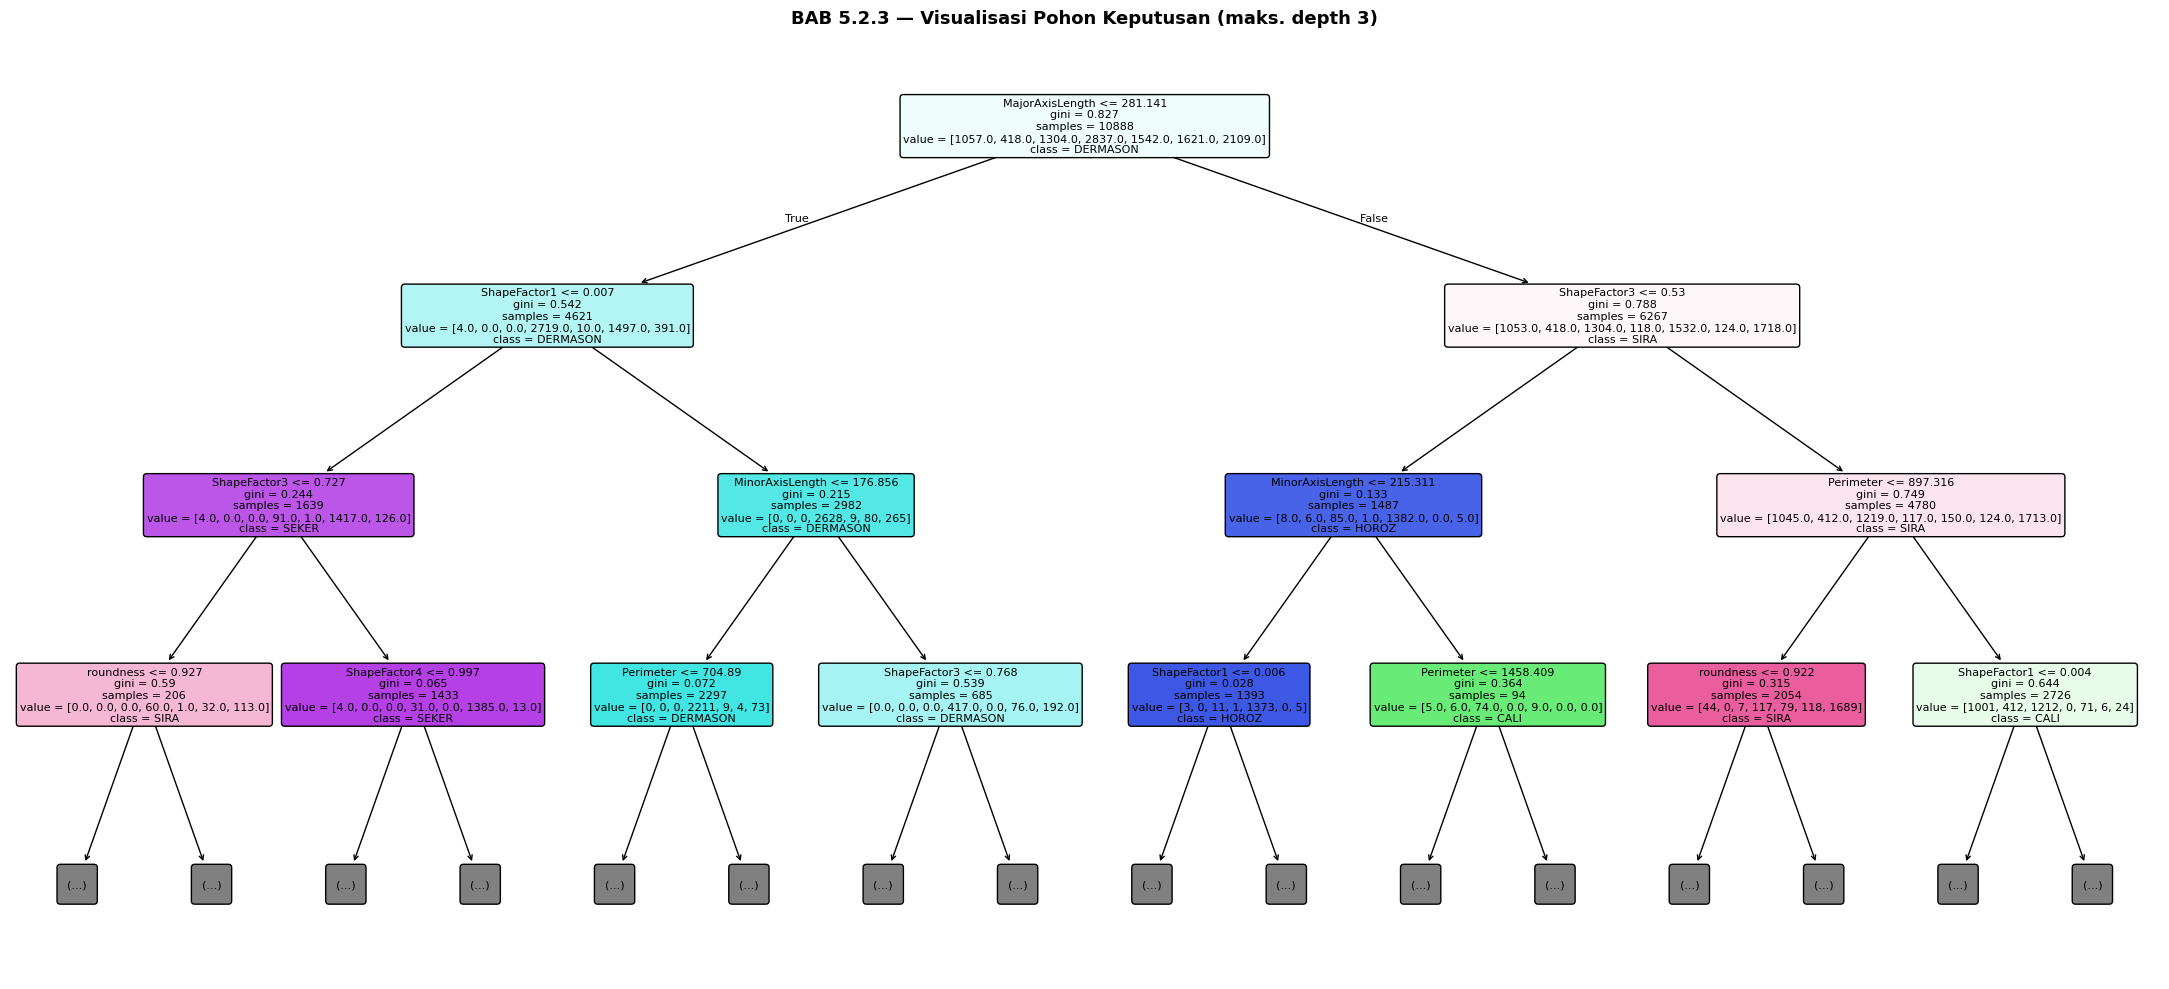

In [7]:
# 5.2.3 Visualisasi Pohon Keputusan
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

if 'dt_model' not in globals():
    raise RuntimeError("Model Decision Tree belum ada. Jalankan subbab 5.2.1 terlebih dahulu.")
if 'X' not in globals():
    raise RuntimeError("Fitur X belum tersedia. Jalankan subbab 5.1.1 terlebih dahulu.")

class_names = [str(c) for c in y_encoder.classes_] if 'y_encoder' in globals() else None

plt.figure(figsize=(22, 10))
plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=class_names,
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)
plt.title('BAB 5.2.3 — Visualisasi Pohon Keputusan (maks. depth 3)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 5.3 Naive Bayes (Gaussian)


#### 5.3.1 Melatih Model Naive Bayes


In [8]:
# 5.3.1 Melatih Model Naive Bayes
from sklearn.naive_bayes import GaussianNB

if 'X_train' not in globals() or 'y_train' not in globals():
    raise RuntimeError("Data train belum tersedia. Jalankan subbab 5.1.1 terlebih dahulu.")

nb_model = GaussianNB()
nb_model.fit(X_train, y_train)

print('Model Naive Bayes berhasil dilatih.')

Model Naive Bayes berhasil dilatih.


#### 5.3.2 Prediksi dengan Model Naive Bayes


In [9]:
# 5.3.2 Prediksi dengan Model Naive Bayes
if 'nb_model' not in globals():
    raise RuntimeError("Model Naive Bayes belum ada. Jalankan subbab 5.3.1 terlebih dahulu.")
if 'X_test' not in globals():
    raise RuntimeError("X_test belum tersedia. Jalankan subbab 5.1.1 terlebih dahulu.")

y_pred_nb = nb_model.predict(X_test)
print(f'Jumlah prediksi test Naive Bayes: {len(y_pred_nb)} sampel')

Jumlah prediksi test Naive Bayes: 2723 sampel


## 6. Evaluasi Model


### 6.1 Evaluasi KNN


#### 6.1.1 Accuracy Score


In [10]:
# 6.1.1 Accuracy Score
from sklearn.metrics import accuracy_score, f1_score

if 'y_pred_knn' not in globals():
    if 'knn_model' in globals() and 'X_test_scaled' in globals():
        y_pred_knn = knn_model.predict(X_test_scaled)
    else:
        raise RuntimeError("Prediksi KNN belum ada. Jalankan subbab 5.1.3 terlebih dahulu.")
if 'y_test' not in globals():
    raise RuntimeError("y_test belum tersedia. Jalankan subbab 5.1.1 terlebih dahulu.")

acc_knn = accuracy_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn, average='weighted')
print(f'Akurasi KNN: {acc_knn:.4f}')
print(f'Weighted F1-Score KNN: {f1_knn:.4f}')

Akurasi KNN: 0.9188
Weighted F1-Score KNN: 0.9190


#### 6.1.2 Classification Report (Precision, Recall, F1-Score)


In [11]:
# 6.1.2 Classification Report (Precision, Recall, F1-Score)
from sklearn.metrics import classification_report

if 'y_pred_knn' not in globals():
    if 'knn_model' in globals() and 'X_test_scaled' in globals():
        y_pred_knn = knn_model.predict(X_test_scaled)
    else:
        raise RuntimeError("Prediksi KNN belum ada. Jalankan subbab 5.1.3 terlebih dahulu.")
if 'y_test' not in globals():
    raise RuntimeError("y_test belum tersedia. Jalankan subbab 5.1.1 terlebih dahulu.")

if 'y_encoder' in globals():
    print('Classification Report KNN:')
    print(classification_report(y_test, y_pred_knn, target_names=y_encoder.classes_))
else:
    print('Classification Report KNN:')
    print(classification_report(y_test, y_pred_knn))

Classification Report KNN:
              precision    recall  f1-score   support

    BARBUNYA       0.97      0.87      0.92       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.92      0.96      0.94       326
    DERMASON       0.92      0.91      0.91       709
       HOROZ       0.96      0.95      0.95       386
       SEKER       0.94      0.94      0.94       406
        SIRA       0.84      0.88      0.86       527

    accuracy                           0.92      2723
   macro avg       0.93      0.93      0.93      2723
weighted avg       0.92      0.92      0.92      2723



#### 6.1.3 Confusion Matrix KNN


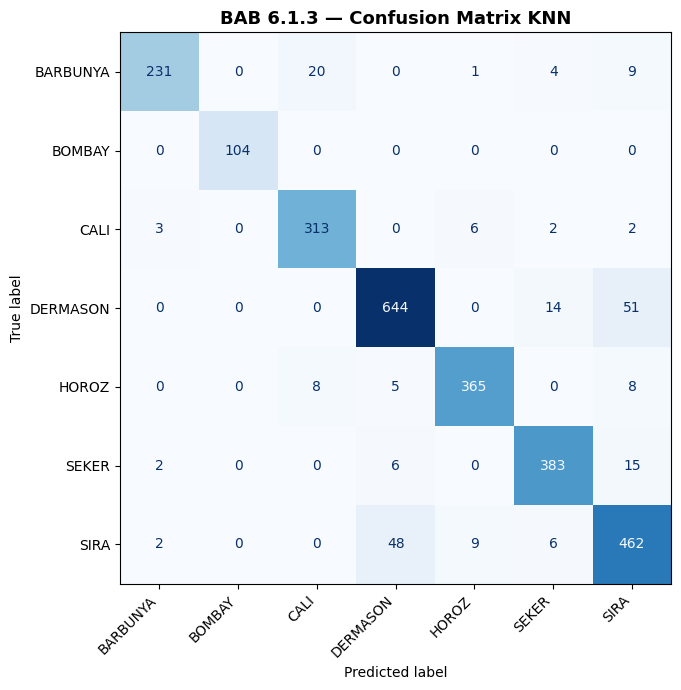

In [12]:
# 6.1.3 Confusion Matrix KNN
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

if 'y_pred_knn' not in globals():
    if 'knn_model' in globals() and 'X_test_scaled' in globals():
        y_pred_knn = knn_model.predict(X_test_scaled)
    else:
        raise RuntimeError("Prediksi KNN belum ada. Jalankan subbab 5.1.3 terlebih dahulu.")
if 'y_test' not in globals():
    raise RuntimeError("y_test belum tersedia. Jalankan subbab 5.1.1 terlebih dahulu.")

cm_knn = confusion_matrix(y_test, y_pred_knn)
fig, ax = plt.subplots(figsize=(9, 7))
labels = y_encoder.classes_ if 'y_encoder' in globals() else None
disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=labels)
disp.plot(ax=ax, cmap='Blues', values_format='d', colorbar=False)
plt.title('BAB 6.1.3 — Confusion Matrix KNN', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### 6.2 Evaluasi Decision Tree


#### 6.2.1 Accuracy Score


In [13]:
# 6.2.1 Accuracy Score
from sklearn.metrics import accuracy_score, f1_score

if 'y_pred_dt' not in globals():
    if 'dt_model' in globals() and 'X_test' in globals():
        y_pred_dt = dt_model.predict(X_test)
    else:
        raise RuntimeError("Prediksi Decision Tree belum ada. Jalankan subbab 5.2.2 terlebih dahulu.")
if 'y_test' not in globals():
    raise RuntimeError("y_test belum tersedia. Jalankan subbab 5.1.1 terlebih dahulu.")

acc_dt = accuracy_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt, average='weighted')
print(f'Akurasi Decision Tree: {acc_dt:.4f}')
print(f'Weighted F1-Score Decision Tree: {f1_dt:.4f}')

Akurasi Decision Tree: 0.8920
Weighted F1-Score Decision Tree: 0.8916


#### 6.2.2 Classification Report (Precision, Recall, F1-Score)


In [14]:
# 6.2.2 Classification Report (Precision, Recall, F1-Score)
from sklearn.metrics import classification_report

if 'y_pred_dt' not in globals():
    if 'dt_model' in globals() and 'X_test' in globals():
        y_pred_dt = dt_model.predict(X_test)
    else:
        raise RuntimeError("Prediksi Decision Tree belum ada. Jalankan subbab 5.2.2 terlebih dahulu.")
if 'y_test' not in globals():
    raise RuntimeError("y_test belum tersedia. Jalankan subbab 5.1.1 terlebih dahulu.")

if 'y_encoder' in globals():
    print('Classification Report Decision Tree:')
    print(classification_report(y_test, y_pred_dt, target_names=y_encoder.classes_))
else:
    print('Classification Report Decision Tree:')
    print(classification_report(y_test, y_pred_dt))

Classification Report Decision Tree:
              precision    recall  f1-score   support

    BARBUNYA       0.88      0.91      0.89       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.92      0.91      0.92       326
    DERMASON       0.88      0.90      0.89       709
       HOROZ       0.94      0.91      0.93       386
       SEKER       0.91      0.95      0.93       406
        SIRA       0.83      0.79      0.81       527

    accuracy                           0.89      2723
   macro avg       0.91      0.91      0.91      2723
weighted avg       0.89      0.89      0.89      2723



#### 6.2.3 Confusion Matrix Decision Tree


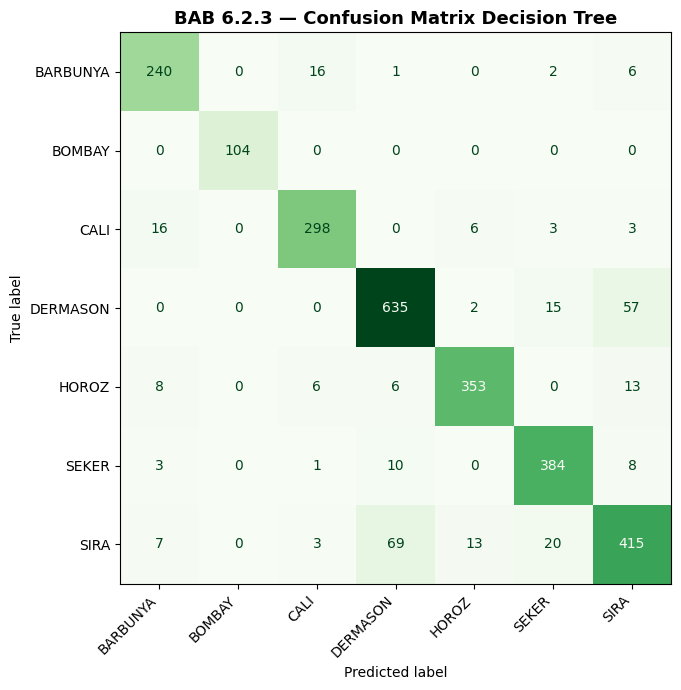

In [15]:
# 6.2.3 Confusion Matrix Decision Tree
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

if 'y_pred_dt' not in globals():
    if 'dt_model' in globals() and 'X_test' in globals():
        y_pred_dt = dt_model.predict(X_test)
    else:
        raise RuntimeError("Prediksi Decision Tree belum ada. Jalankan subbab 5.2.2 terlebih dahulu.")
if 'y_test' not in globals():
    raise RuntimeError("y_test belum tersedia. Jalankan subbab 5.1.1 terlebih dahulu.")

cm_dt = confusion_matrix(y_test, y_pred_dt)
fig, ax = plt.subplots(figsize=(9, 7))
labels = y_encoder.classes_ if 'y_encoder' in globals() else None
disp = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=labels)
disp.plot(ax=ax, cmap='Greens', values_format='d', colorbar=False)
plt.title('BAB 6.2.3 — Confusion Matrix Decision Tree', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### 6.3 Evaluasi Naive Bayes


#### 6.3.1 Accuracy Score


In [16]:
# 6.3.1 Accuracy Score
from sklearn.metrics import accuracy_score, f1_score

if 'y_pred_nb' not in globals():
    if 'nb_model' in globals() and 'X_test' in globals():
        y_pred_nb = nb_model.predict(X_test)
    else:
        raise RuntimeError("Prediksi Naive Bayes belum ada. Jalankan subbab 5.3.2 terlebih dahulu.")
if 'y_test' not in globals():
    raise RuntimeError("y_test belum tersedia. Jalankan subbab 5.1.1 terlebih dahulu.")

acc_nb = accuracy_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb, average='weighted')
print(f'Akurasi Naive Bayes: {acc_nb:.4f}')
print(f'Weighted F1-Score Naive Bayes: {f1_nb:.4f}')

Akurasi Naive Bayes: 0.7639
Weighted F1-Score Naive Bayes: 0.7615


#### 6.3.2 Classification Report (Precision, Recall, F1-Score)


In [17]:
# 6.3.2 Classification Report (Precision, Recall, F1-Score)
from sklearn.metrics import classification_report

if 'y_pred_nb' not in globals():
    if 'nb_model' in globals() and 'X_test' in globals():
        y_pred_nb = nb_model.predict(X_test)
    else:
        raise RuntimeError("Prediksi Naive Bayes belum ada. Jalankan subbab 5.3.2 terlebih dahulu.")
if 'y_test' not in globals():
    raise RuntimeError("y_test belum tersedia. Jalankan subbab 5.1.1 terlebih dahulu.")

if 'y_encoder' in globals():
    print('Classification Report Naive Bayes:')
    print(classification_report(y_test, y_pred_nb, target_names=y_encoder.classes_))
else:
    print('Classification Report Naive Bayes:')
    print(classification_report(y_test, y_pred_nb))

Classification Report Naive Bayes:
              precision    recall  f1-score   support

    BARBUNYA       0.68      0.46      0.55       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.68      0.83      0.75       326
    DERMASON       0.87      0.83      0.85       709
       HOROZ       0.78      0.79      0.79       386
       SEKER       0.68      0.71      0.70       406
        SIRA       0.73      0.76      0.75       527

    accuracy                           0.76      2723
   macro avg       0.77      0.77      0.77      2723
weighted avg       0.77      0.76      0.76      2723



#### 6.3.3 Confusion Matrix Naive Bayes


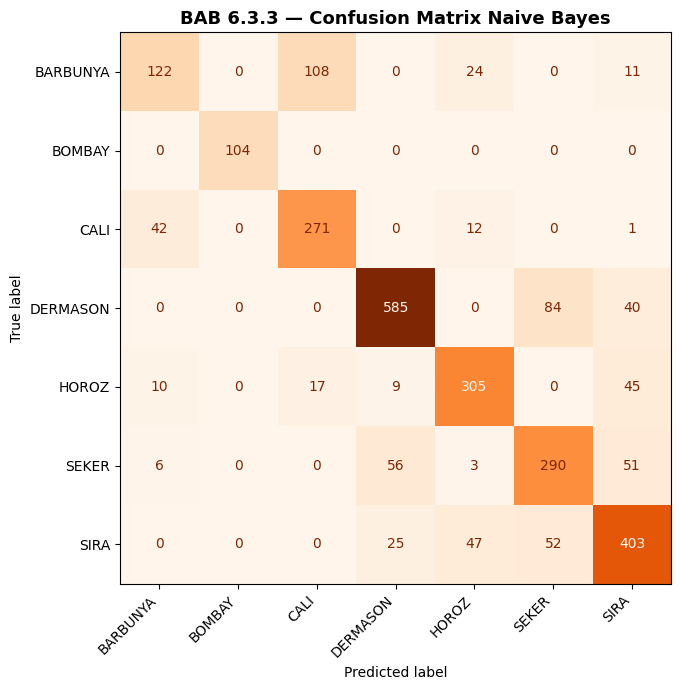

In [18]:
# 6.3.3 Confusion Matrix Naive Bayes
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

if 'y_pred_nb' not in globals():
    if 'nb_model' in globals() and 'X_test' in globals():
        y_pred_nb = nb_model.predict(X_test)
    else:
        raise RuntimeError("Prediksi Naive Bayes belum ada. Jalankan subbab 5.3.2 terlebih dahulu.")
if 'y_test' not in globals():
    raise RuntimeError("y_test belum tersedia. Jalankan subbab 5.1.1 terlebih dahulu.")

cm_nb = confusion_matrix(y_test, y_pred_nb)
fig, ax = plt.subplots(figsize=(9, 7))
labels = y_encoder.classes_ if 'y_encoder' in globals() else None
disp = ConfusionMatrixDisplay(confusion_matrix=cm_nb, display_labels=labels)
disp.plot(ax=ax, cmap='Oranges', values_format='d', colorbar=False)
plt.title('BAB 6.3.3 — Confusion Matrix Naive Bayes', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### 6.4 Perbandingan Awal Ketiga Model


Perbandingan awal ketiga model:
        Model  Accuracy  Weighted F1-Score
          KNN  0.918840           0.919010
Decision Tree  0.892031           0.891630
  Naive Bayes  0.763863           0.761474

Model dengan accuracy tertinggi: KNN
Model dengan weighted F1-score tertinggi: KNN


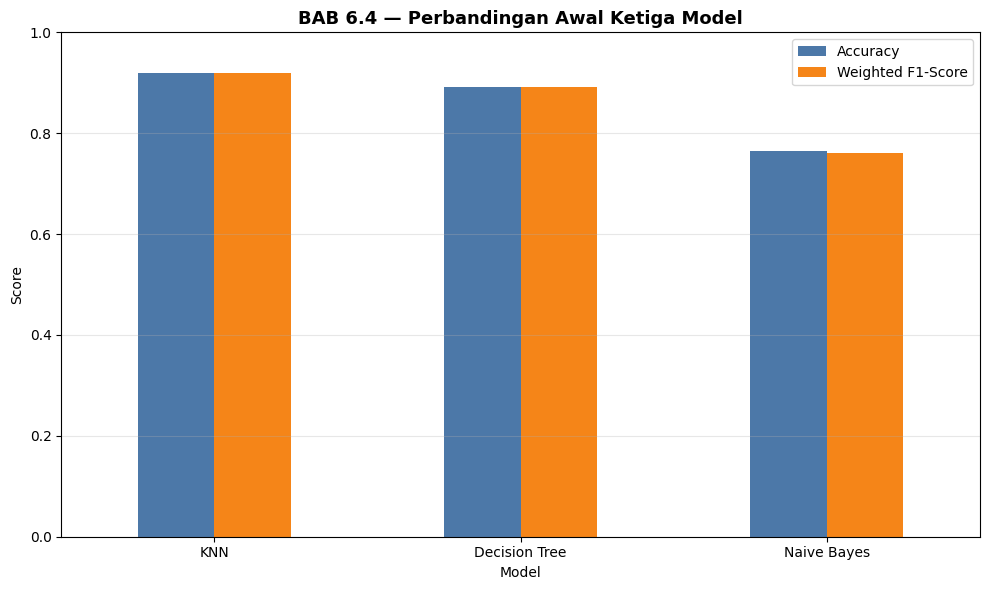

In [31]:
comparison_df = pd.DataFrame([
    {'Model': 'KNN', 'Accuracy': acc_knn, 'Weighted F1-Score': f1_knn},
    {'Model': 'Decision Tree', 'Accuracy': acc_dt, 'Weighted F1-Score': f1_dt},
    {'Model': 'Naive Bayes', 'Accuracy': acc_nb, 'Weighted F1-Score': f1_nb}
], columns=['Model', 'Accuracy', 'Weighted F1-Score'])

print('Perbandingan awal ketiga model:')
print(comparison_df.to_string(index=False))

best_model_accuracy = comparison_df.loc[comparison_df['Accuracy'].idxmax(), 'Model']
best_model_f1 = comparison_df.loc[comparison_df['Weighted F1-Score'].idxmax(), 'Model']

print(f"\nModel dengan accuracy tertinggi: {best_model_accuracy}")
print(f"Model dengan weighted F1-score tertinggi: {best_model_f1}")

plot_df = comparison_df.set_index('Model')
ax = plot_df.plot(kind='bar', figsize=(10, 6), rot=0, color=['#4C78A8', '#F58518'])
ax.set_title('BAB 6.4 — Perbandingan Awal Ketiga Model', fontsize=13, fontweight='bold')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.0)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Hyperparameter Tuning


### 7.1 Tuning KNN (GridSearchCV)


#### 7.1.1 Definisi Parameter Grid KNN


#### 7.1.2 Proses GridSearchCV KNN


#### 7.1.3 Parameter Terbaik KNN


#### 7.1.4 Evaluasi KNN Setelah Tuning


### 7.2 Tuning Decision Tree (GridSearchCV)


#### 7.2.1 Definisi Parameter Grid Decision Tree


#### 7.2.2 Proses GridSearchCV Decision Tree


#### 7.2.3 Parameter Terbaik Decision Tree


#### 7.2.4 Evaluasi Decision Tree Setelah Tuning


### 7.3 Tuning Naive Bayes (GridSearchCV)


#### 7.3.1 Definisi Parameter Grid Naive Bayes


#### 7.3.2 Proses GridSearchCV Naive Bayes


#### 7.3.3 Parameter Terbaik Naive Bayes


#### 7.3.4 Evaluasi Naive Bayes Setelah Tuning


### 7.4 Perbandingan Model Sebelum dan Sesudah Tuning


## 8. Ensemble Model


### 8.1 Hard Voting Classifier


#### 8.1.1 Membangun Hard Voting Classifier


#### 8.1.2 Evaluasi Hard Voting Classifier


#### 8.1.3 Confusion Matrix Hard Voting


### 8.2 Soft Voting Classifier


#### 8.2.1 Membangun Soft Voting Classifier


#### 8.2.2 Evaluasi Soft Voting Classifier


#### 8.2.3 Confusion Matrix Soft Voting


### 8.3 Stacking Classifier


#### 8.3.1 Membangun Stacking Classifier


#### 8.3.2 Evaluasi Stacking Classifier


#### 8.3.3 Confusion Matrix Stacking


## 9. Perbandingan Semua Model


### 9.1 Tabel Perbandingan Seluruh Model


### 9.2 Visualisasi Perbandingan Accuracy


### 9.3 Visualisasi Perbandingan F1-Score


## 10. Kesimpulan dan Analisis


### 10.1 Ringkasan Hasil


### 10.2 Model Terbaik


### 10.3 Pengaruh Ensemble terhadap Performa


### 10.4 Keterbatasan dan Saran
